In [1]:
import math
import numpy as np
import torch
from torch import nn 
from d2l import torch as d2l
#

$$
y=5+1.2 x-3.4 \frac{x^2}{2!}+5.6 \frac{x^3}{3!}+\epsilon \text { where } \epsilon \sim \mathcal{N}\left(0,0.1^2\right)
$$

In [2]:
max_degree = 20 #多项式的最大阶数
n_train,n_test = 100,100 #训练数据集和测试数据集的大小
true_w = np.zeros(max_degree) 
true_w[0:4] = np.array([5,1.2,-3.4,5.6])

features = np.random.normal(size=(n_train+n_test,1))#列向量
np.random.shuffle(features)
poly_features = np.power(features,np.arange(max_degree).reshape(1,-1))#计算[[x1^0,x1^1,...],[x2^0,x2^1,...],...],这里用到了广播机制
for i in range(max_degree):
    poly_features[:,i]/=math.gamma(i+1)#gamma(n)=(n-1)!点除以
#labels的维度: (n_train+n_test,)
labels = np.dot(poly_features,true_w)
labels += np.random.normal(scale=0.1,size=labels.shape)

In [3]:
#numpy array 转换成tensor
true_w,features,poly_features,labels = [torch.tensor(x,dtype=torch.float32) for x in [true_w,features,poly_features,labels]]
features[:2],poly_features[:2,:],labels[:2]

(tensor([[1.9019],
         [0.9525]]),
 tensor([[1.0000e+00, 1.9019e+00, 1.8086e+00, 1.1465e+00, 5.4515e-01, 2.0736e-01,
          6.5729e-02, 1.7858e-02, 4.2455e-03, 8.9716e-04, 1.7063e-04, 2.9501e-05,
          4.6756e-06, 6.8403e-07, 9.2924e-08, 1.1782e-08, 1.4005e-09, 1.5668e-10,
          1.6555e-11, 1.6571e-12],
         [1.0000e+00, 9.5248e-01, 4.5361e-01, 1.4402e-01, 3.4293e-02, 6.5327e-03,
          1.0371e-03, 1.4111e-04, 1.6801e-05, 1.7780e-06, 1.6935e-07, 1.4664e-08,
          1.1639e-09, 8.5279e-11, 5.8019e-12, 3.6841e-13, 2.1931e-14, 1.2288e-15,
          6.5021e-17, 3.2595e-18]]),
 tensor([7.5882, 5.4424]))

In [4]:
def evaluate_loss(net,data_iter,loss):
    metric = d2l.Accumulator(2)
    for X,y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out,y)
        metric.add(l.sum(),l.numel())
    return metric[0]/metric[1]

In [5]:
import torch.nn
from d2l import torch as d2l
from IPython import display


class Accumulator:
    """
    在n个变量上累加
    """

    def __init__(self, n):
        self.data = [0.0] * n       # 创建一个长度为 n 的列表，初始化所有元素为0.0。

    def add(self, *args):           # 累加
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):                # 重置累加器的状态，将所有元素重置为0.0
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):     # 获取所有数据
        return self.data[idx]


def accuracy(y_hat, y):
    """
    计算正确的数量
    :param y_hat:
    :param y:
    :return:
    """
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)            # 在每行中找到最大值的索引，以确定每个样本的预测类别
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())


def evaluate_accuracy(net, data_iter):
    """
    计算指定数据集的精度
    :param net:
    :param data_iter:
    :return:
    """
    if isinstance(net, torch.nn.Module):
        net.eval()                  # 通常会关闭一些在训练时启用的行为
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


class Animator:
    """
    在动画中绘制数据
    """

    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量的绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend
        )
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        """
        向图表中添加多个数据点
        :param x:
        :param y:
        :return:
        """
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)


def train_epoch_ch3(net, train_iter, loss, updater):
    """
    训练模型一轮
    :param net:是要训练的神经网络模型
    :param train_iter:是训练数据的数据迭代器，用于遍历训练数据集
    :param loss:是用于计算损失的损失函数
    :param updater:是用于更新模型参数的优化器
    :return:
    """
    if isinstance(net, torch.nn.Module):  # 用于检查一个对象是否属于指定的类（或类的子类）或数据类型。
        net.train()

    # 训练损失总和， 训练准确总和， 样本数
    metric = Accumulator(3)

    for X, y in train_iter:  # 计算梯度并更新参数
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):  # 用于检查一个对象是否属于指定的类（或类的子类）或数据类型。
            # 使用pytorch内置的优化器和损失函数
            updater.zero_grad()
            l.mean().backward()  # 方法用于计算损失的平均值
            updater.step()
        else:
            # 使用定制（自定义）的优化器和损失函数
            l.sum().backward()
            updater(X.shape())
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回训练损失和训练精度
    return metric[0] / metric[2], metric[1] / metric[2]


def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """
    训练模型（）
    :param net:
    :param train_iter:
    :param test_iter:
    :param loss:
    :param num_epochs:
    :param updater:
    :return:
    """
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        trans_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, trans_metrics + (test_acc,))
        train_loss, train_acc = trans_metrics
        print(trans_metrics)


def predict_ch3(net, test_iter, n=6):
    """
    进行预测
    :param net:
    :param test_iter:
    :param n:
    :return:
    """
    global X, y
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + "\n" + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n]
    )
    d2l.plt.show()


In [10]:
def train(train_features,test_features,train_labels,test_labels,num_epochs=400):
    loss = nn.MSELoss(reduction='None')
    input_shape = train_features.shape[-1]
    #不设置偏置，因为已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape,1,bias=False))
    batch_size = min(10,train_labels.shape[0])
    train_iter = d2l.load_array((train_features,train_labels.reshape(-1,1)),batch_size)
    test_iter = d2l.load_array((test_features,test_labels.reshape(-1,1)),batch_size,is_train=False)
    trainer = torch.optim.SGD(net.parameters(),lr=0.01)
    animator = d2l.Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[1,num_epochs],ylim=[1e-3,1e2],legend=['train','test'])
    for epoch in range(num_epochs):
        train_epoch_ch3(net,train_iter,loss,trainer)
        if epoch == 0 or (epoch+1)%20 == 0:
            animator.add(epoch+1,(evaluate_loss(net,train_iter,loss),evaluate_loss(net,test_iter,loss)))
    print('weight:',net[0].weight.data.numpy())
        

ValueError: None is not a valid value for reduction

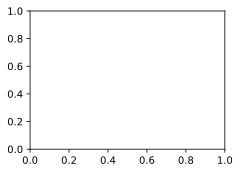

In [9]:
train(poly_features[:n_train,:4],poly_features[n_train:,:4],labels[:n_train],labels[n_train:])